In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/NASSCOM/Dr Dipanwita D/course materals/synthetic_biased_hiring_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Candidate_ID,Age,Gender,Education,Experience_Years,Skill_Score,Interview_Score,Location,Previous_Company,Selected
0,1,49,Female,Master,4.7,73.7,56.8,Tier2,MidTech,0
1,2,35,Male,Bachelor,5.5,77.3,95.3,Tier2,NoExperience,0
2,3,28,Male,Bachelor,9.5,63.8,74.1,Tier1,MidTech,0
3,4,41,Female,Bachelor,5.3,75.7,64.5,Tier2,MidTech,1
4,5,39,Male,PhD,3.5,84.1,59.3,Tier1,TopTech,1


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (5000, 10)

Columns:
['Candidate_ID', 'Age', 'Gender', 'Education', 'Experience_Years', 'Skill_Score', 'Interview_Score', 'Location', 'Previous_Company', 'Selected']


In [ ]:
print(df["Gender"].value_counts())

Gender
Male      2513
Female    2487
Name: count, dtype: int64


In [ ]:
print(df["Selected"].value_counts())

Selected
1    2913
0    2087
Name: count, dtype: int64


In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (5000, 10)

Data Types:
Candidate_ID          int64
Age                   int64
Gender               object
Education            object
Experience_Years    float64
Skill_Score         float64
Interview_Score     float64
Location             object
Previous_Company     object
Selected              int64
dtype: object

Missing Values:
Candidate_ID        0
Age                 0
Gender              0
Education           0
Experience_Years    0
Skill_Score         0
Interview_Score     0
Location            0
Previous_Company    0
Selected            0
dtype: int64


In [ ]:
print(df["Gender"].value_counts())

print("\nGender Percentage:")
print(df["Gender"].value_counts(normalize=True) * 100)

Gender
Male      2513
Female    2487
Name: count, dtype: int64

Gender Percentage:
Gender
Male      50.26
Female    49.74
Name: proportion, dtype: float64


In [ ]:
selection_by_gender = df.groupby("Gender")["Selected"].mean() * 100

print("Selection Rate by Gender:")
print(selection_by_gender)

Selection Rate by Gender:
Gender
Female    44.069160
Male      72.304019
Name: Selected, dtype: float64


In [ ]:
print(
    pd.crosstab(
        df["Gender"],
        df["Selected"],
        margins=True
    )
)

Selected     0     1   All
Gender                    
Female    1391  1096  2487
Male       696  1817  2513
All       2087  2913  5000


In [ ]:
print(
    pd.crosstab(
        df["Gender"],
        df["Location"],
        normalize="index"
    ).round(3)
)

Location  Metro  Tier1  Tier2  Tier3
Gender                              
Female    0.261  0.255  0.290  0.194
Male      0.500  0.258  0.175  0.066


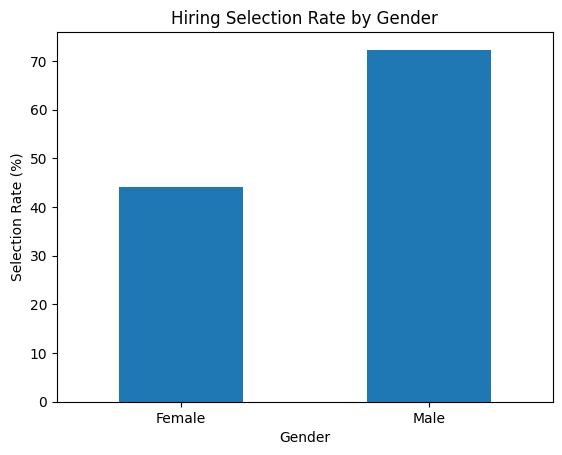

In [ ]:
import matplotlib.pyplot as plt

selection_by_gender.plot(kind="bar")

plt.title("Hiring Selection Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Selection Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
X = df.drop(columns=["Candidate_ID", "Selected"])
y = df["Selected"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'Gender', 'Education', 'Experience_Years', 'Skill_Score', 'Interview_Score', 'Location', 'Previous_Company']

Target:
Selected


In [ ]:
categorical_features = [
    "Gender",
    "Education",
    "Location",
    "Previous_Company"
]

numerical_features = [
    "Age",
    "Experience_Years",
    "Skill_Score",
    "Interview_Score"
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000
Testing samples: 1000


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ]
)

In [ ]:
pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = pipeline.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[1 0 0 0 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.667

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.58      0.59       417
           1       0.71      0.73      0.72       583

    accuracy                           0.67      1000
   macro avg       0.66      0.65      0.65      1000
weighted avg       0.66      0.67      0.67      1000



In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results.head()

,Age,Gender,Education,Experience_Years,Skill_Score,Interview_Score,Location,Previous_Company,Actual,Predicted
2683,39,Female,Master,3.2,65.7,74.9,Metro,Startup,0,1
4577,32,Female,Bachelor,7.0,65.7,58.3,Tier2,MidTech,0,0
2933,30,Female,Master,4.6,80.1,70.3,Tier1,NoExperience,1,0
2510,39,Female,Master,0.0,80.7,72.2,Tier1,LocalFirm,1,0
1558,54,Male,Diploma,3.0,71.6,82.4,Tier1,NoExperience,1,0


In [ ]:
female = results[results["Gender"] == "Female"]

cm_female = confusion_matrix(
    female["Actual"],
    female["Predicted"]
)

print("Female Confusion Matrix:")
print(cm_female)

Female Confusion Matrix:
[[234  53]
 [149  90]]


In [ ]:
male = results[results["Gender"] == "Male"]

cm_male = confusion_matrix(
    male["Actual"],
    male["Predicted"]
)

print("Male Confusion Matrix:")
print(cm_male)

Male Confusion Matrix:
[[  6 124]
 [  7 337]]


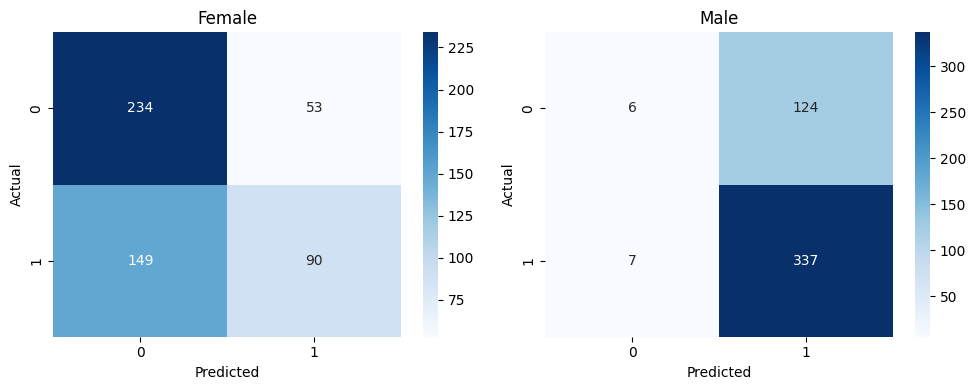

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(
    cm_female,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Female")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_male,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[1]
)

axes[1].set_title("Male")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
def subgroup_metrics(data, group_name):
    cm = confusion_matrix(
        data["Actual"],
        data["Predicted"]
    )

    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"\n{group_name}")
    print("----------------------")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)
    print("TPR:", round(tpr, 4))
    print("FPR:", round(fpr, 4))

    return tpr, fpr

In [ ]:
female_tpr, female_fpr = subgroup_metrics(
    female,
    "Female"
)

male_tpr, male_fpr = subgroup_metrics(
    male,
    "Male"
)


Female
----------------------
TN: 234
FP: 53
FN: 149
TP: 90
TPR: 0.3766
FPR: 0.1847

Male
----------------------
TN: 6
FP: 124
FN: 7
TP: 337
TPR: 0.9797
FPR: 0.9538


In [ ]:
female_selection_rate = female["Predicted"].mean()
male_selection_rate = male["Predicted"].mean()

print("Female selection rate:", round(female_selection_rate, 4))
print("Male selection rate:", round(male_selection_rate, 4))

dp_difference = male_selection_rate - female_selection_rate

dp_ratio = (
    female_selection_rate / male_selection_rate
    if male_selection_rate > 0 else 0
)

print("\nDemographic Parity Difference:", round(dp_difference, 4))
print("Demographic Parity Ratio:", round(dp_ratio, 4))

Female selection rate: 0.2719
Male selection rate: 0.9726

Demographic Parity Difference: 0.7007
Demographic Parity Ratio: 0.2795


In [ ]:
eo_difference = male_tpr - female_tpr

print("Female TPR:", round(female_tpr, 4))
print("Male TPR:", round(male_tpr, 4))
print("Equal Opportunity Difference:", round(eo_difference, 4))

Female TPR: 0.3766
Male TPR: 0.9797
Equal Opportunity Difference: 0.6031


In [ ]:
tpr_difference = abs(male_tpr - female_tpr)
fpr_difference = abs(male_fpr - female_fpr)

print("TPR Difference:", round(tpr_difference, 4))
print("FPR Difference:", round(fpr_difference, 4))

TPR Difference: 0.6031
FPR Difference: 0.7692


In [ ]:
fairness_results = pd.DataFrame({
    "Metric": [
        "Selection Rate",
        "TPR",
        "FPR"
    ],
    "Female": [
        female_selection_rate,
        female_tpr,
        female_fpr
    ],
    "Male": [
        male_selection_rate,
        male_tpr,
        male_fpr
    ]
})

fairness_results.round(4)

,Metric,Female,Male
0,Selection Rate,0.2719,0.9726
1,TPR,0.3766,0.9797
2,FPR,0.1847,0.9538


In [ ]:
summary = pd.DataFrame({
    "Fairness Metric": [
        "Demographic Parity Difference",
        "Demographic Parity Ratio",
        "Equal Opportunity Difference",
        "TPR Difference",
        "FPR Difference"
    ],
    "Value": [
        dp_difference,
        dp_ratio,
        eo_difference,
        tpr_difference,
        fpr_difference
    ]
})

summary.round(4)

,Fairness Metric,Value
0,Demographic Parity Difference,0.7007
1,Demographic Parity Ratio,0.2795
2,Equal Opportunity Difference,0.6031
3,TPR Difference,0.6031
4,FPR Difference,0.7692


In [ ]:
!pip install -q shap

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
rf_model = pipeline.named_steps["classifier"]

print(rf_model)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)


In [ ]:
X_test_transformed = pipeline.named_steps["preprocessor"].transform(X_test)

print("Transformed shape:", X_test_transformed.shape)

Transformed shape: (1000, 19)


In [ ]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

print(feature_names)

['cat__Gender_Female' 'cat__Gender_Male' 'cat__Education_Bachelor'
 'cat__Education_Diploma' 'cat__Education_Master' 'cat__Education_PhD'
 'cat__Location_Metro' 'cat__Location_Tier1' 'cat__Location_Tier2'
 'cat__Location_Tier3' 'cat__Previous_Company_LocalFirm'
 'cat__Previous_Company_MidTech' 'cat__Previous_Company_NoExperience'
 'cat__Previous_Company_Startup' 'cat__Previous_Company_TopTech'
 'num__Age' 'num__Experience_Years' 'num__Skill_Score'
 'num__Interview_Score']


In [ ]:
explainer = shap.TreeExplainer(rf_model)

In [ ]:
shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [ ]:
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_values_positive = shap_values[:, :, 1]
    else:
        shap_values_positive = shap_values

print("SHAP shape:", shap_values_positive.shape)

SHAP shape: (1000, 19)


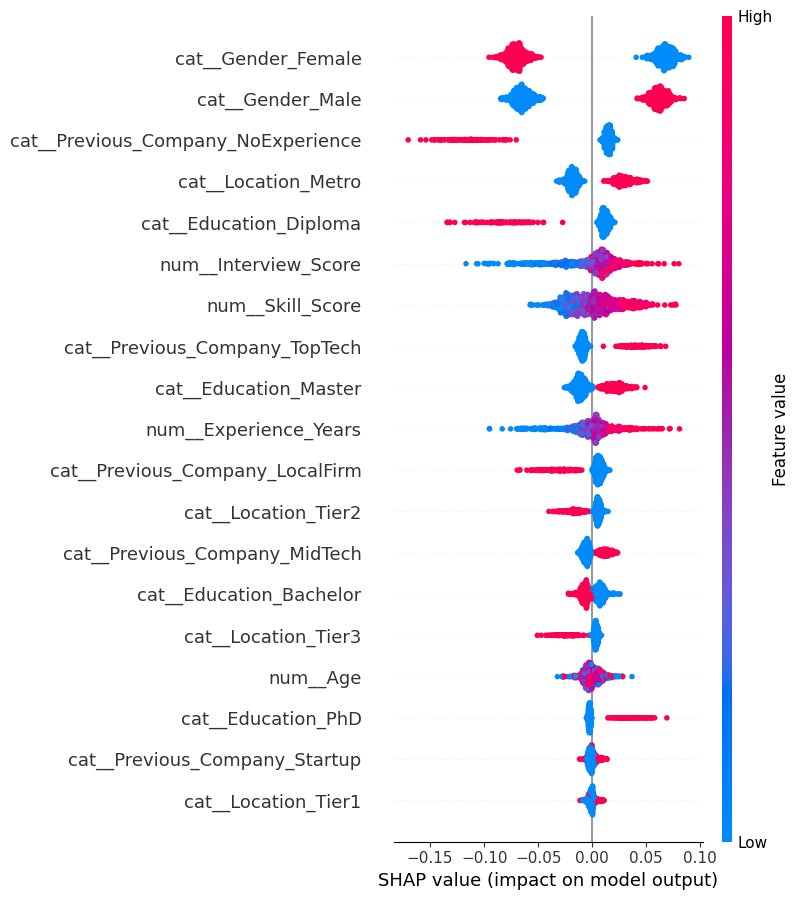

In [ ]:
shap.summary_plot(
    shap_values_positive,
    X_test_transformed,
    feature_names=feature_names
)

In [ ]:
mean_abs_shap = np.abs(shap_values_positive).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
0,cat__Gender_Female,0.068959
1,cat__Gender_Male,0.063427
12,cat__Previous_Company_NoExperience,0.027044
6,cat__Location_Metro,0.022683
3,cat__Education_Diploma,0.019578
18,num__Interview_Score,0.018526
17,num__Skill_Score,0.018075
14,cat__Previous_Company_TopTech,0.014693
4,cat__Education_Master,0.014616
16,num__Experience_Years,0.014074


In [ ]:
gender_features = shap_importance[
    shap_importance["Feature"].str.contains("Gender", case=False)
]

gender_features

,Feature,Mean_Absolute_SHAP
0,cat__Gender_Female,0.068959
1,cat__Gender_Male,0.063427


In [ ]:
location_features = shap_importance[
    shap_importance["Feature"].str.contains("Location", case=False)
]

location_features

,Feature,Mean_Absolute_SHAP
6,cat__Location_Metro,0.022683
8,cat__Location_Tier2,0.008345
9,cat__Location_Tier3,0.006128
7,cat__Location_Tier1,0.002179


In [ ]:
pd.crosstab(
    df["Gender"],
    df["Location"],
    normalize="index"
).round(3)

Location,Metro,Tier1,Tier2,Tier3
Gender,,,,
Female,0.261,0.255,0.290,0.194
Male,0.500,0.258,0.175,0.066


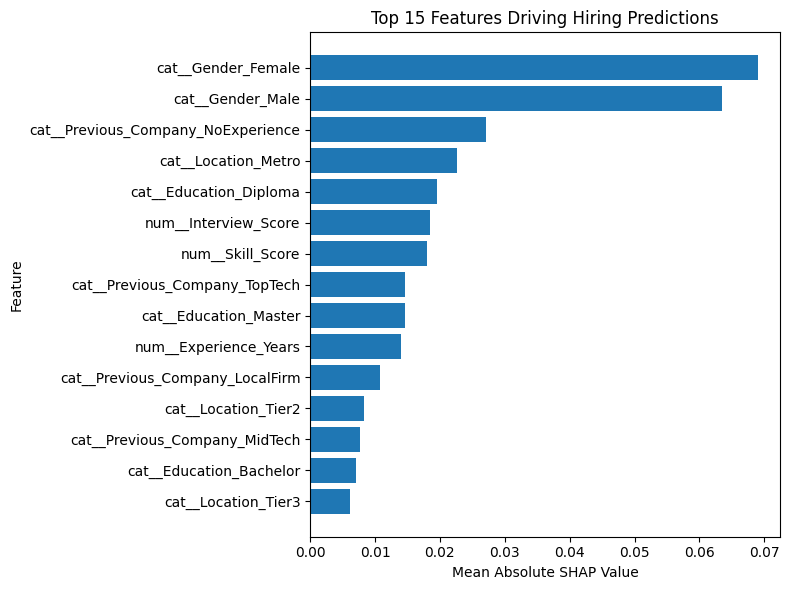

In [ ]:
top15 = shap_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top15["Feature"],
    top15["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features Driving Hiring Predictions")

plt.tight_layout()
plt.show()

In [ ]:
# Selection rates
female_selection = female["Predicted"].mean()
male_selection = male["Predicted"].mean()

# TPR and FPR
female_tpr, female_fpr = subgroup_metrics(female, "Female")
male_tpr, male_fpr = subgroup_metrics(male, "Male")

# Fairness differences
dp_difference = male_selection - female_selection
dp_ratio = female_selection / male_selection if male_selection > 0 else np.nan

eo_difference = male_tpr - female_tpr

tpr_difference = abs(male_tpr - female_tpr)
fpr_difference = abs(male_fpr - female_fpr)

# Model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Female Selection Rate:", round(female_selection, 4))
print("Male Selection Rate:", round(male_selection, 4))
print("Female TPR:", round(female_tpr, 4))
print("Male TPR:", round(male_tpr, 4))
print("Female FPR:", round(female_fpr, 4))
print("Male FPR:", round(male_fpr, 4))


Female
----------------------
TN: 234
FP: 53
FN: 149
TP: 90
TPR: 0.3766
FPR: 0.1847

Male
----------------------
TN: 6
FP: 124
FN: 7
TP: 337
TPR: 0.9797
FPR: 0.9538
Accuracy: 0.667
Female Selection Rate: 0.2719
Male Selection Rate: 0.9726
Female TPR: 0.3766
Male TPR: 0.9797
Female FPR: 0.1847
Male FPR: 0.9538


In [ ]:
top_features = shap_importance.head(10)["Feature"].tolist()

print("Top 10 features influencing the model:")
for i, feature in enumerate(top_features, 1):
    print(i, feature)

Top 10 features influencing the model:
1 cat__Gender_Female
2 cat__Gender_Male
3 cat__Previous_Company_NoExperience
4 cat__Location_Metro
5 cat__Education_Diploma
6 num__Interview_Score
7 num__Skill_Score
8 cat__Previous_Company_TopTech
9 cat__Education_Master
10 num__Experience_Years


In [ ]:
gender_importance = shap_importance[
    shap_importance["Feature"].str.contains("Gender", case=False)
]["Mean_Absolute_SHAP"].sum()

location_importance = shap_importance[
    shap_importance["Feature"].str.contains("Location", case=False)
]["Mean_Absolute_SHAP"].sum()

print("Gender SHAP importance:", round(gender_importance, 4))
print("Location SHAP importance:", round(location_importance, 4))

Gender SHAP importance: 0.1324
Location SHAP importance: 0.0393


In [ ]:
report = f"""
========================================================
        RESPONSIBLE AI – HIRING BIAS REPORT
========================================================

1. MODEL PERFORMANCE
--------------------
The Random Forest hiring classifier achieved an accuracy
of {accuracy:.2%} on the test dataset.

2. SELECTION RATE BY GENDER
---------------------------
Female candidates predicted as selected:
{female_selection:.2%}

Male candidates predicted as selected:
{male_selection:.2%}

Difference in selection rates:
{abs(dp_difference):.2%}

3. DEMOGRAPHIC PARITY
---------------------
Demographic Parity Difference:
{dp_difference:.4f}

Demographic Parity Ratio:
{dp_ratio:.4f}

4. EQUAL OPPORTUNITY
--------------------
Female True Positive Rate:
{female_tpr:.2%}

Male True Positive Rate:
{male_tpr:.2%}

Difference in TPR:
{abs(eo_difference):.2%}

5. EQUALIZED ODDS
-----------------
Female False Positive Rate:
{female_fpr:.2%}

Male False Positive Rate:
{male_fpr:.2%}

TPR difference:
{tpr_difference:.4f}

FPR difference:
{fpr_difference:.4f}

6. SHAP EXPLAINABILITY
----------------------
The features with the greatest influence on the model
were:

{chr(10).join([f"- {f}" for f in top_features])}

Gender-related SHAP importance:
{gender_importance:.4f}

Location-related SHAP importance:
{location_importance:.4f}

7. PLAIN-LANGUAGE FINDING
-------------------------
The model's overall accuracy should not be considered
sufficient evidence that the hiring system is fair.

The analysis compares model outcomes across demographic
groups and examines whether the model treats those groups
differently.

SHAP analysis identifies which features contribute most
to the model's predictions. Location was also examined as
a possible proxy feature because demographic attributes
can sometimes be indirectly represented by other variables.

These results should be investigated before using such a
model for real-world hiring decisions.

========================================================
"""

print(report)


        RESPONSIBLE AI – HIRING BIAS REPORT

1. MODEL PERFORMANCE
--------------------
The Random Forest hiring classifier achieved an accuracy
of 66.70% on the test dataset.

2. SELECTION RATE BY GENDER
---------------------------
Female candidates predicted as selected:
27.19%

Male candidates predicted as selected:
97.26%

Difference in selection rates:
70.07%

3. DEMOGRAPHIC PARITY
---------------------
Demographic Parity Difference:
0.7007

Demographic Parity Ratio:
0.2795

4. EQUAL OPPORTUNITY
--------------------
Female True Positive Rate:
37.66%

Male True Positive Rate:
97.97%

Difference in TPR:
60.31%

5. EQUALIZED ODDS
-----------------
Female False Positive Rate:
18.47%

Male False Positive Rate:
95.38%

TPR difference:
0.6031

FPR difference:
0.7692

6. SHAP EXPLAINABILITY
----------------------
The features with the greatest influence on the model
were:

- cat__Gender_Female
- cat__Gender_Male
- cat__Previous_Company_NoExperience
- cat__Location_Metro
- cat__Education_D

In [ ]:
report_path = "/content/drive/MyDrive/NASSCOM/Dr Dipanwita D/course materals/bias_report.txt"

with open(report_path, "w") as f:
    f.write(report)

print("Report saved to:")
print(report_path)

Report saved to:
/content/drive/MyDrive/NASSCOM/Dr Dipanwita D/course materals/bias_report.txt
